#Taller 3 - Metodos Computacionales
## Sofia Moscoso Ortiz
## 1015068640

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

### **1**
Supongamos que tienes un conjunto de datos que registra la posición de un objeto en movimiento en intervalos de tiempo iguales. Los datos son los siguientes: $t=[0,2,4,6,8]$ en segundos y $x=[0,20,80,180,320]$ en metros encuentra el pilnomio de iterpolación de lagrnage, grafica y responde:

¿Cuál es la posición del objeto en el instante de tiempo $t = 5$ segundos?

¿Cuál es la velocidad del objeto en el instante de tiempo $t = 5$ segundos?

In [58]:
def lagrange(X, Y, x):
    n = len(X)
    result = 0.0

    for i in range(n):
        term = Y[i]
        for j in range(n):
            if i != j:
                term *= (x - X[j]) / (X[i] - X[j])
        result += term
    return result

In [59]:
t , x =[0,2,4,6,8] , [0,20,80,180,320]

In [60]:
#¿Cuál es la posición del objeto en el instante de tiempo  t=5  segundos? , ¿Cuál es la velocidad del objeto en el instante de tiempo  t=5  segundos?
print(f""" La posicion del objeto en el instante de 5 segundos fue: {lagrange(t , x ,5)} metros
            la velocidad del objeto en el instante de 5 segundos era: {lagrange(t , x ,5)/5}m/s^2""" )

 La posicion del objeto en el instante de 5 segundos fue: 125.0 metros
            la velocidad del objeto en el instante de 5 segundos era: 25.0m/s^2


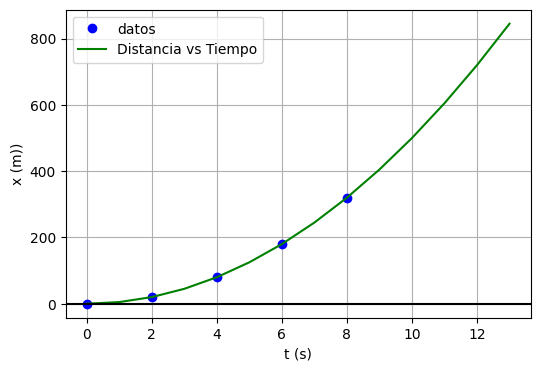

In [61]:
a = np.arange(14)
plt.figure(figsize=(6,4))
plt.plot( t , x , "o", color = "blue" , label= "datos")
plt.plot( a , lagrange( t , x , a ) , "-",  color = "green" , label= "Distancia vs Tiempo")
plt.axhline( y= 0 , color = "black")
plt.xlabel("t (s)")
plt.ylabel("x (m))")
plt.legend()
plt.grid()

###**2**
Concidere el problema anteriror y agrege los datos de $v=[10,15,25,30,35]$ en $m/s$ encuentre el polinomio de hermite y determine la velocidad del objeto en $t = 5$ segundos.

In [62]:
t , x , v =[0,2,4,6,8] , [0,20,80,180,320] , [10,15,25,30,35]

In [63]:
#Interpolacion de Hermite

def hermite(xi , yi , fi, x):

  def dupli_list(list):
    dupli = []
    for i in range(len(list)):
      dupli.append(list[i])
      dupli.append(list[i])
    return dupli

  xi = dupli_list(xi)
  yi = dupli_list(yi)
  fi = dupli_list(fi)

  divisores = []
  coeficientes =  []
  filtro = yi

  for k in range(1,len(filtro)+1):

    for i in range(len(filtro)-1):

      if k == 1 and i%2 == 0:
        if i == 0:
          y = fi[i]
          divisores.append(y)
        else:
          y = fi[i]
          divisores.append(y)
      else:
        y = ( filtro[i+1] - filtro[i] ) / ( xi[i+k] - xi[i] )
        divisores.append(y)


    coeficientes.append(filtro[0])
    filtro = divisores
    divisores = []

  P = coeficientes[0]
  multi = 1
  for i in range(len(xi)-1):
    multi = (x - xi[i]) * multi
    P = P + ( coeficientes[i+1] * multi)
  return P

In [64]:
#encuentre el polinomio de hermite y determine la velocidad del objeto en  t=5  segundos.
print(f""" la velocidad del objeto en el instante de 5 segundos era de: {hermite(t , x , v ,5)/5} m/s^2""" )

 la velocidad del objeto en el instante de 5 segundos era de: 24.80865478515625 m/s^2


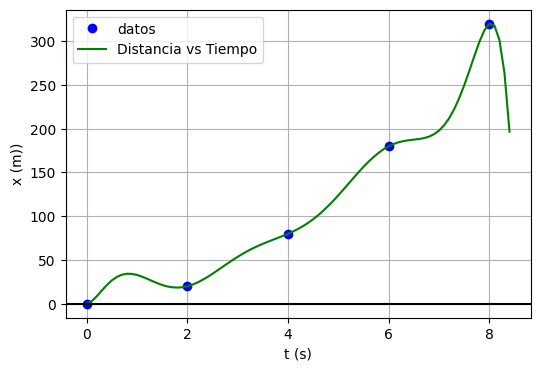

In [65]:
a = np.arange(0,8.5,0.1)
plt.figure(figsize=(6,4))
plt.plot( t , x , "o", color = "blue" , label= "datos")
plt.plot( a , hermite( t , x , v , a ) , "-",  color = "green" , label= "Distancia vs Tiempo")
plt.axhline( y= 0 , color = "black")
plt.xlabel("t (s)")
plt.ylabel("x (m))")
plt.legend()
plt.grid()

###**3**
Supongamos que tienes datos de temperaturas registradas en diferentes momentos del día en una ubicación específica. Los datos son los siguientes:
$t=[0,2,4,6,8]$ en horas y T=[20,22,24,27,30] utiliza la interpolación de Newton con diferencias divididas para encontrar un polinomio que describa cómo varía la temperatura en función del tiempo.

¿Cuál es la temperatura estimada a las 3 horas?

¿Cuál es la temperatura estimada a las 5 horas?

¿Cuál es la temperatura estimada a las 7 horas?

In [66]:
#Metodo de newton
def delta_div(xi , yi , x):
  divisores = []
  coeficientes =  []
  filtro = yi

  for k in range(1,len(filtro)+1):
    for i in range(len(filtro)-1):
      y = ( filtro[i+1] - filtro[i] ) / ( xi[i+k] - xi[i] )
      divisores.append(y)

    coeficientes.append(filtro[0])
    filtro = divisores
    divisores = []

  P = coeficientes[0]
  multi = 1
  for i in range(len(xi)-1):
    multi = (x - xi[i]) * multi
    P = P + ( coeficientes[i+1] * multi)
  return P

In [67]:
t , T =[0,2,4,6,8] , [20,22,24,27,30]

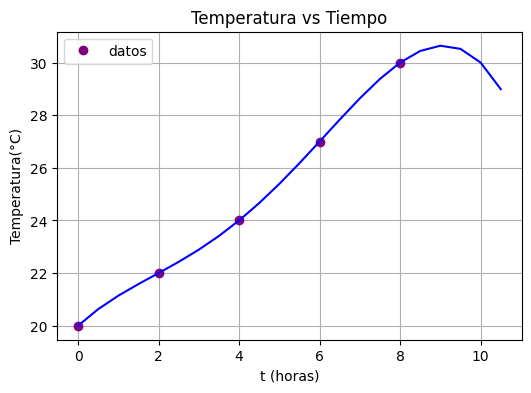

In [68]:
x = np.arange(0 ,11 ,0.5)
plt.figure(figsize=(6,4))

plt.plot( t , T , "o", color = "purple" , label= "datos")
plt.plot( x , delta_div( t , T , x ) , "-",  color = "blue" )
plt.xlabel("t (horas)")
plt.ylabel("Temperatura(°C)")
plt.title("Temperatura vs Tiempo")
plt.legend()
plt.grid()
plt.show()

In [69]:
#¿Cuál es la temperatura estimada a las 3 horas? , ¿Cuál es la temperatura estimada a las 5 horas? , ¿Cuál es la temperatura estimada a las 7 horas?
print(f""" La temperatura esperada en:
          3 horas es : {delta_div(t ,T ,3)} °C
          5 horas es:   {delta_div(t ,T ,5)} °C
          7 horas es: {delta_div(t ,T ,7)} °C """)

 La temperatura esperada en:
          3 horas es : 22.890625 °C
          5 horas es:   25.390625 °C
          7 horas es: 28.640625 °C 


###**4**
Imagina que estás analizando el movimiento de un automóvil que viaja por una carretera recta. Durante un viaje, se registraron la velocidad del automóvil en varios momentos. Los datos son los siguientes: $t=[0,2,4,6,8]$ en segundos y $v=[0,10,20,30,40]$ en $m/s$

**A** Consulta el método de cubic spline e implementalo en python.

**B**Utiliza esta función para calcular la velocidad estimada en los momentos dados (3 segundos y 5 segundos) y para encontrar el tiempo en el que la velocidad es igual a 35 m/s.


In [70]:
t , v =[0,2,4,6,8] , [0,10,20,30,40]

In [71]:
def spline(X , Y , x):
  h = np.diff(X)
  delta_y = np.diff(Y)
  delta2_y = np.diff(delta_y)
  dy2_dx2 = np.zeros(len(X))
  dy2_dx2[1:-1] = delta2_y / h[1:]

  a = Y[:-1]
  b = delta_y / h - h * dy2_dx2[:-1] / 2
  c = dy2_dx2 / 2
  d = (dy2_dx2[1:] - dy2_dx2[:-1]) / (6 * h)

  i = np.searchsorted(X, x)
  if i == 0:
      i = 1
  elif i == len(X):
      i = len(X) - 1
  xi = X[i - 1]
  yi = a[i - 1]
  bi = b[i - 1]
  ci = c[i - 1]
  di = d[i - 1]
  dx = x - xi
  return yi + bi * dx + ci * dx**2 + di * dx**3

In [72]:
#Utiliza esta función para calcular la velocidad estimada en los momentos dados (3 segundos y 5 segundos)
print(f""" La velocidadtemperatura estimada en:
          3 segundos es : {spline(t ,v , 3)} m/s^2
          5 segundos es:   {spline(t ,v ,5)} m/s^2 """)

 La velocidadtemperatura estimada en:
          3 segundos es : 15.0 m/s^2
          5 segundos es:   25.0 m/s^2 


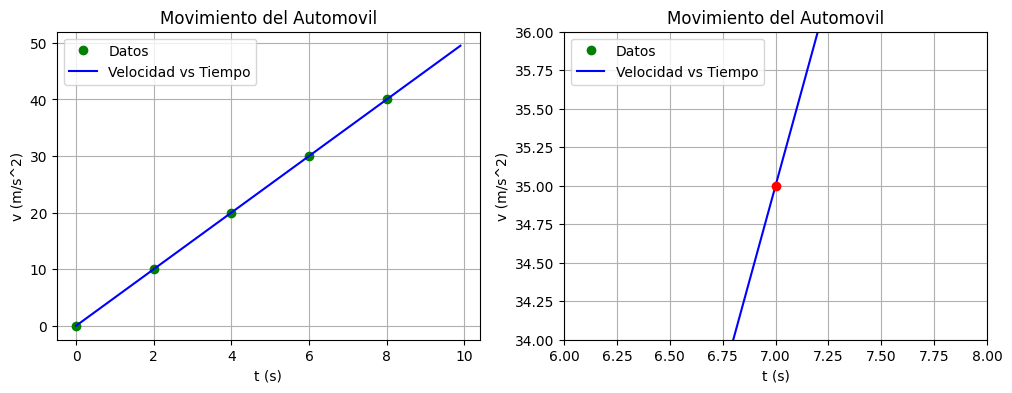

In [73]:
a = np.arange(0, 10, 0.1)
y = [spline(t , v , a) for a in a]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(t, v, 'o', color = "green" , label='Datos')
plt.plot( a , y , color = "blue" , label='Velocidad vs Tiempo')
plt.legend(loc='best')
plt.xlabel('t (s)')
plt.ylabel('v (m/s^2)')
plt.title('Movimiento del Automovil')
plt.grid()

plt.subplot(1,2,2)
plt.plot(t, v, 'o', color = "green" , label='Datos')
plt.plot( a , y , color = "blue" , label='Velocidad vs Tiempo')
plt.plot(  [7] , [35] , "o" , color = "red")
plt.legend(loc='best')
plt.xlim(6,8)
plt.ylim(34,36)
plt.xlabel('t (s)')
plt.ylabel('v (m/s^2)')
plt.title('Movimiento del Automovil')
plt.grid()

plt.show()


In [74]:
# para encontrar el tiempo en el que la velocidad es igual a 35 m/s.
print(f"Observamos que el tiempo en el que la velocidad es igual a 35m/s^2 es de 7 segundos: {spline(t ,v ,7)} m/s^2 ")

Observamos que el tiempo en el que la velocidad es igual a 35m/s^2 es de 7 segundos: 35.0 m/s^2 


### **5**
Supongamos que estás trabajando en un proyecto astronómico que involucra el seguimiento de un cometa en su órbita alrededor del Sol. Tienes datos de la posición del cometa registrados en diferentes momentos a lo largo de varios años. Los datos incluyen la distancia del cometa al Sol y el ángulo polar en coordenadas polares.

Los datos disponibles son los siguientes:

$t=[0,1,2,3,4,5]$ en años

$D=[2.5,2.8,3.3,4.0,4.9,6.2]$ en UA

$\theta=[30,45,60,80,110,150]$ en grados

Usa el método de interpolación de tu elección para encontrar el polinomio de interpolación y responder:

¿Cuál es la distancia estimada del cometa al Sol y el ángulo polar en $t = 2.5$ años?

¿En qué año el cometa alcanzará su máxima distancia al Sol?

¿Cuál es el ángulo polar estimado en ese momento?

In [75]:
#Metodo de newton
def delta_div(xi , yi , x):
  divisores = []
  coeficientes =  []
  filtro = yi

  for k in range(1,len(filtro)+1):
    for i in range(len(filtro)-1):
      y = ( filtro[i+1] - filtro[i] ) / ( xi[i+k] - xi[i] )
      divisores.append(y)

    coeficientes.append(filtro[0])
    filtro = divisores
    divisores = []

  P = coeficientes[0]
  multi = 1
  for i in range(len(xi)-1):
    multi = (x - xi[i]) * multi
    P = P + ( coeficientes[i+1] * multi)
  return P

In [76]:
t= [0,1,2,3,4,5] #en años
D=[2.5,2.8,3.3,4.0,4.9,6.2] #en UA
angulo=[30,45,60,80,110,150] #en grados

In [77]:
#¿Cuál es la distancia estimada del cometa al Sol y el ángulo polar en  t=2.5  años?
print(f"""la distancia estimada del cometa al Sol y el ángulo polar en  t=2.5  años es:
       distancia de {delta_div(t,D,2.5)} UA y un angulo de: {delta_div(t,angulo,2.5)} grados""")

la distancia estimada del cometa al Sol y el ángulo polar en  t=2.5  años es:
       distancia de 3.62734375 UA y un angulo de: 69.00390625 grados


In [78]:
#¿En qué año el cometa alcanzará su máxima distancia al Sol?
#Pense en analizar los maximos de la funcion directaente desde la grafica, sin embargo, el resultado de esta fue una exponencial (tiende a infinito)
print("El cometa permanecera alejandose de la estrella indefinidamente")

El cometa permanecera alejandose de la estrella indefinidamente


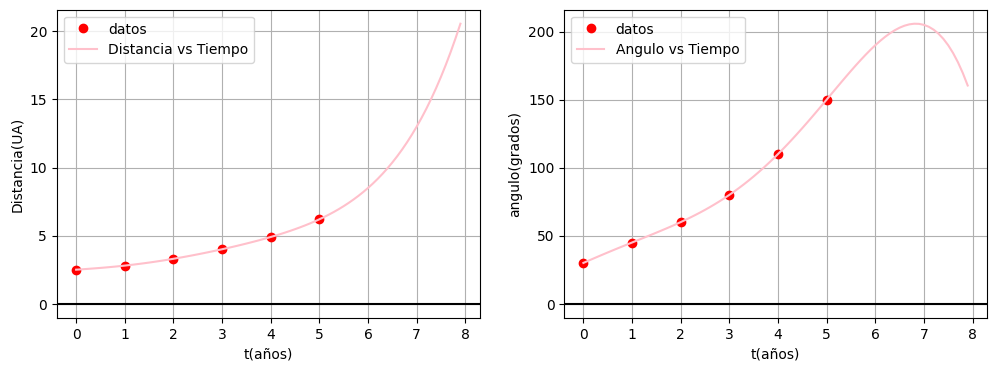

In [80]:
x = np.arange(0,8,0.1)
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot( t , D , "o", color = "red" , label= "datos")
plt.plot( x , delta_div( t , D , x ) , "-",  color = "pink" , label= "Distancia vs Tiempo")
plt.axhline( y= 0 , color = "black")
plt.xlabel("t(años)")
plt.ylabel("Distancia(UA)")
plt.legend()
plt.grid()


plt.subplot(1,2,2)
plt.plot( t , angulo , "o", color = "red" , label= "datos")
plt.plot( x , delta_div( t , angulo , x ) , "-",  color = "pink" , label= "Angulo vs Tiempo")
plt.axhline( y= 0 , color = "black")
plt.xlabel("t(años)")
plt.ylabel("angulo(grados)")
plt.legend()
plt.grid()

plt.show()